# Explore here

📝 Instrucciones
Prediciendo la diabetes
Este conjunto de datos proviene originalmente del Instituto Nacional de Diabetes y Enfermedades Digestivas y Renales. El objetivo es predecir en base a medidas diagnósticas si un paciente tiene o no diabetes.

Paso 1: Carga del conjunto de datos
El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre diabetes.csv. Puedes cargarlo en el código directamente desde el siguiente enlace:

O descargarlo y añadirlo a mano en tu repositorio. En este conjunto de datos encontrarás las siguientes variables:

Pregnancies. Número de embarazos del paciente (numérico)

Glucose. Concentración de glucosa en plasma a las 2 horas de un test de tolerancia oral a la glucosa (numérico)
BloodPressure. Presión arterial diastólica (medida en mm Hg) (numérico)
SkinThickness. Grosor del pliegue cutáneo del tríceps (medida en mm) (numérico)
Insulin. Insulina sérica de 2 horas (medida en mu U/ml) (numérico)
BMI. Índice de masa corporal (numérico)
DiabetesPedigreeFunction. Función de pedigrí de diabetes (numérico)
Age. Edad del paciente (numérico)
Outcome. Variable de clase (0 o 1), siendo 0 negativo en diabetes y 1, positivo (numérico)
Paso 2: Realiza un EDA completo

Paso 2: Realiza un EDA completo
Este segundo paso es vital para asegurar que nos quedamos con las variables estrictamente necesarias y eliminamos las que no son relevantes o no aportan información. Utiliza el Notebook de ejemplo que trabajamos y adáptalo a este caso de uso.

Asegúrate de dividir convenientemente el conjunto de datos en train y test como hemos visto en lecciones anteriores.

Paso 3: Construye un modelo de árbol de decisión
Comienza a resolver el problema implementando un árbol de decisión y analiza cuál de los dos tipos satisface tus necesidades. Entrénalo y analiza sus resultados. Prueba a modificar la función de cálculo de la pureza de los nodos y utiliza todas las disponibles. Descríbelas y analiza sus resultados graficándolos.

Paso 4: Optimiza el modelo anterior
Después de entrenar el árbol con las distintas funciones de pureza, selecciona el mejor de ellos y optimiza sus hiperparámetros utilizando un grid search.

Paso 5: Guarda el modelo
Almacena el modelo en la carpeta correspondiente.

EDA. PARTE 1 CONOCIENDO EL DATASET

In [2]:
# Your code here

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_classif, SelectKBest
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder

url="https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv"
df=pd.read_csv(url)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.shape


(768, 9)

In [5]:
# revisando nulos
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Conclusiones del dataset:
- el dataset tiene 768 filas y 9 columnas (siendo al variable objetivo outcome)
- No hay valores nulos
- Se visualizan que hay 8 variables numéricas y 1 variable categórica binaria (referencia a outcome, ya que esta tiene valores 0 y 1 que indican si un paciente tiene diabetes o no)

2. ELIMINACIÓN DE DUPLICADOS

In [6]:
duplicados = df.duplicated()
num_duplicados = duplicados.sum()

print(f"El dataset tiene {num_duplicados} filas duplicadas")

#si hubiera filas duplicadas 
#seleccionar duplicados
#df_duplicados = df[duplicados]
#print("Filas duplicadas:")
#print(df_duplicados)


El dataset tiene 0 filas duplicadas


CONCLUSIÓN: no se encontraron valores nulos

3. Selección de atributos relevantes

Para este caso, como la variable y es outcome, la cual es binaria. Se considera que todas las variables son relevantes para el modelo predictivo. No se eliminará ninguna.

4. Análisis univariante

4.1. Análisis sobre variables categóricas

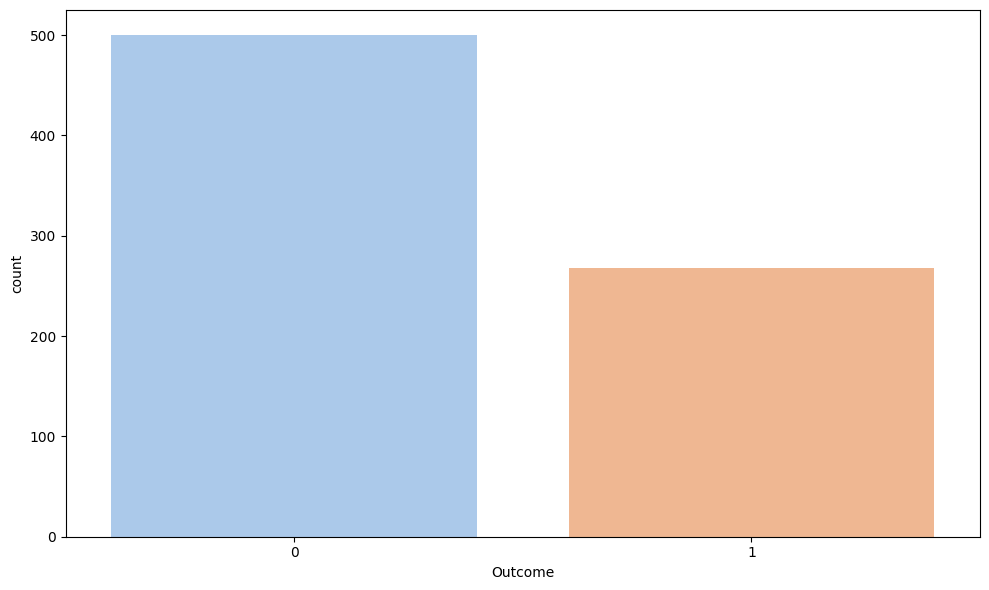

In [7]:
fig, axis = plt.subplots( figsize = (10, 6))

sns.countplot( data = df, x = "Outcome", palette='pastel', hue= "Outcome", legend=False)

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

Se visualiza que la mayoría de pacientes no tienen diabetes 


4.2. Análisis sobre variable numéricas

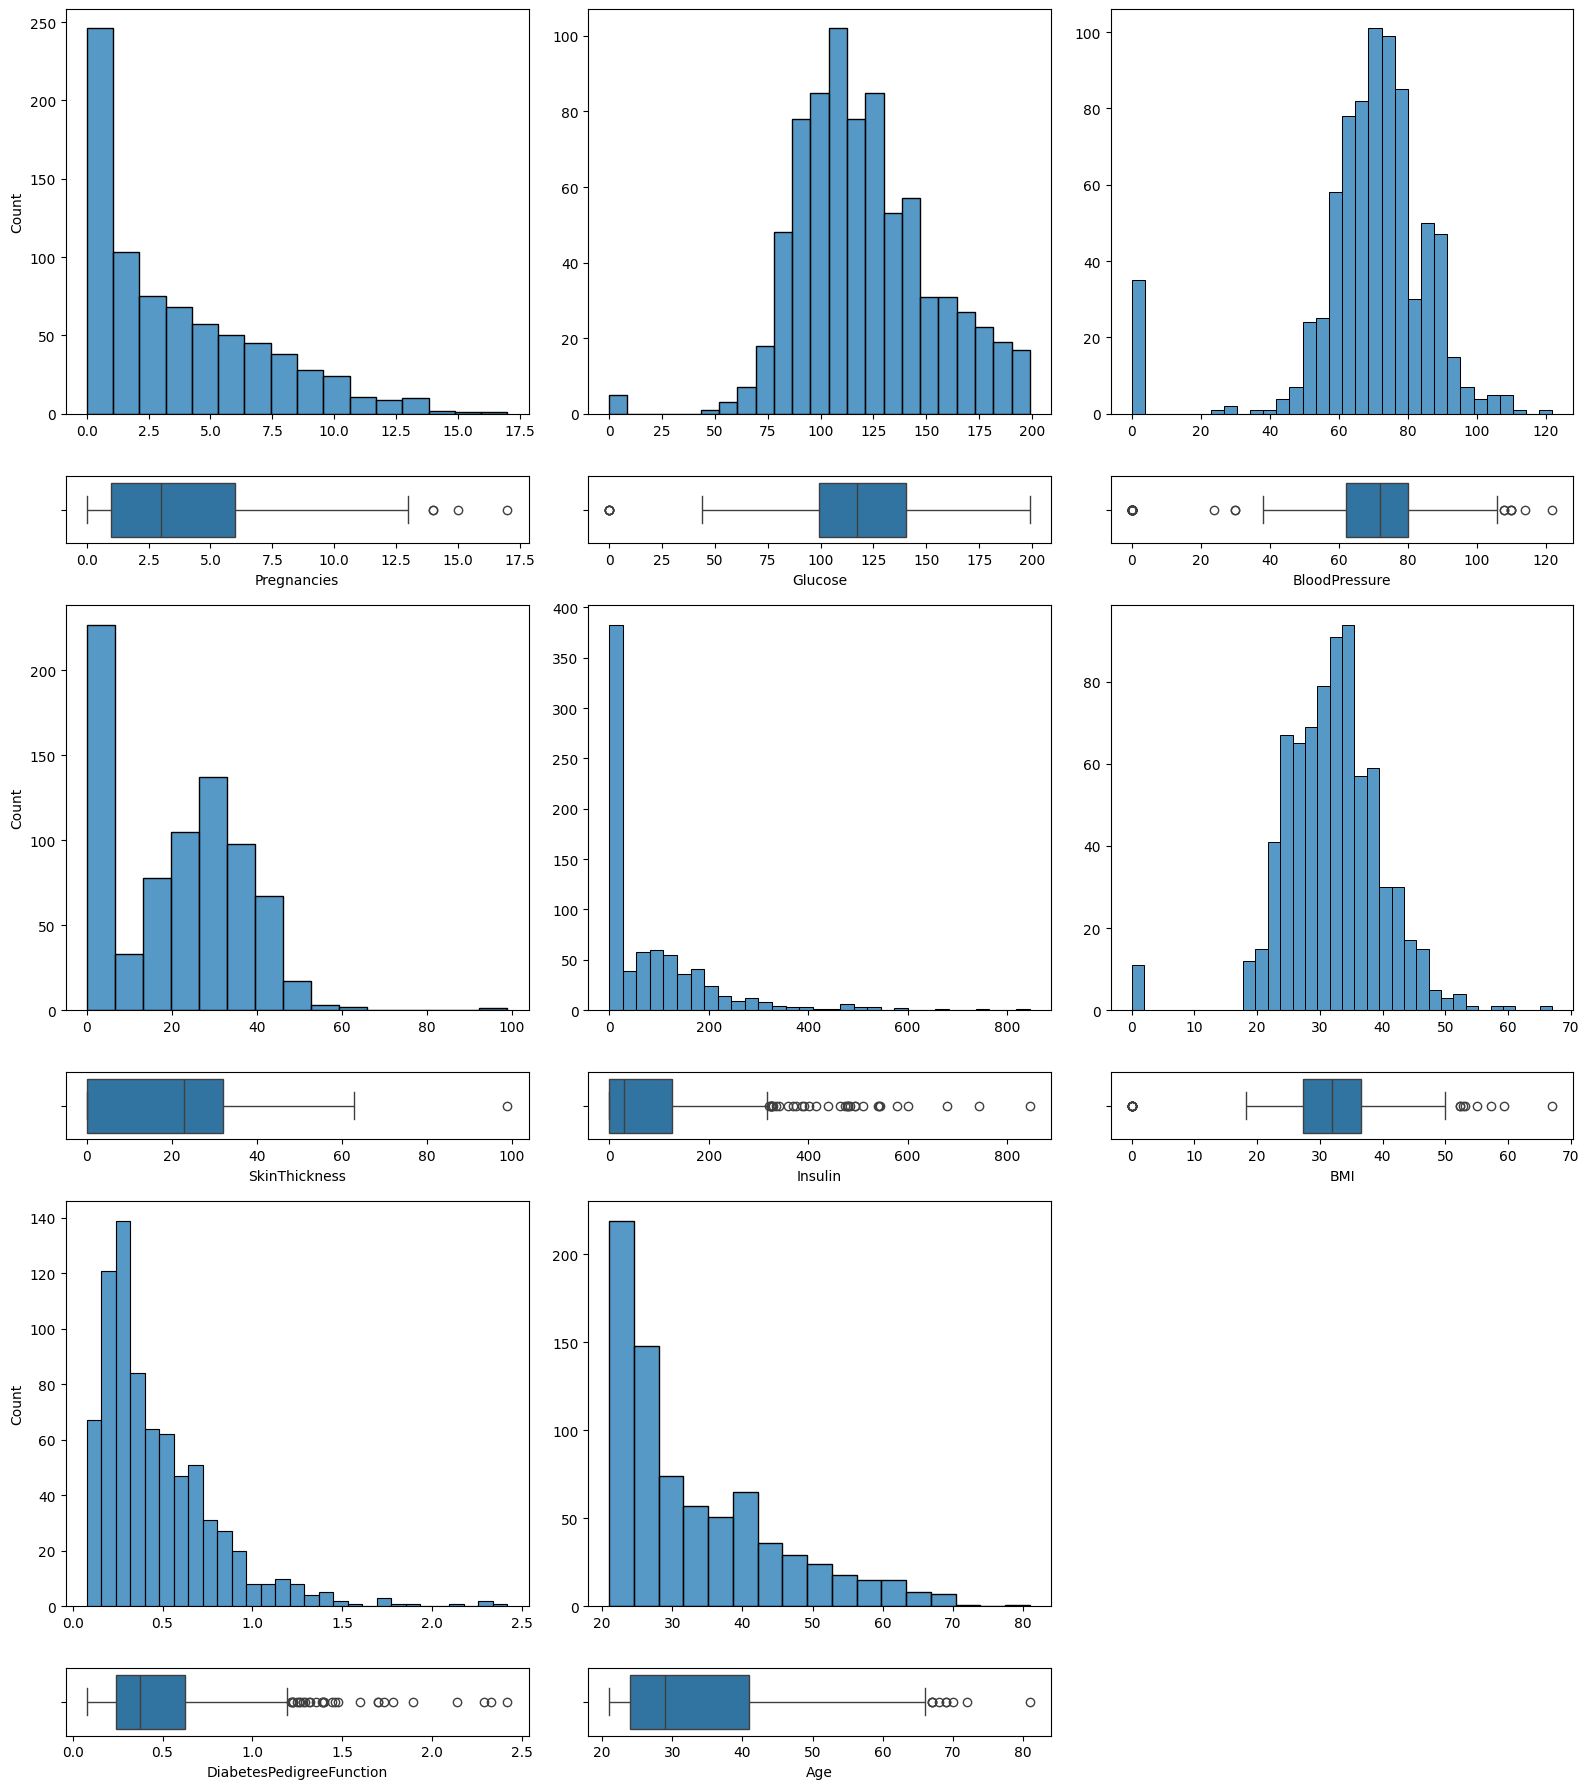

In [8]:
fig, axis = plt.subplots(6, 3, figsize=(16, 18), gridspec_kw={'height_ratios': [6, 1, 6, 1, 6, 1]})


sns.histplot(ax=axis[0, 0], data=df, x="Pregnancies").set(xlabel=None)
sns.boxplot(ax=axis[1, 0], data=df, x="Pregnancies")

sns.histplot(ax=axis[0, 1], data=df, x="Glucose").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[1, 1], data=df, x="Glucose")


sns.histplot(ax=axis[0, 2], data=df, x="BloodPressure").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[1, 2], data=df, x="BloodPressure")


sns.histplot(ax=axis[2, 0], data=df, x="SkinThickness").set(xlabel=None)
sns.boxplot(ax=axis[3, 0], data=df, x="SkinThickness")


sns.histplot(ax=axis[2, 1], data=df, x="Insulin").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[3, 1], data=df, x="Insulin")


sns.histplot(ax=axis[2, 2], data=df, x="BMI").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[3, 2], data=df, x="BMI")


sns.histplot(ax=axis[4, 0], data=df, x="DiabetesPedigreeFunction").set(xlabel=None)
sns.boxplot(ax=axis[5, 0], data=df, x="DiabetesPedigreeFunction")


sns.histplot(ax=axis[4, 1], data=df, x="Age").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[5, 1], data=df, x="Age")



fig.delaxes(axis[4, 2])
fig.delaxes(axis[5, 2])
plt.tight_layout()
plt.show()

conclusiones:
- Se visualizan muchos outliers en variables Insulin, BMI, Pregnancies y DiabetesPedigreeFunction.
- en algunas variables se tienen valores  iguales  a 0 lo que puede significar valores faltantes. Esto ocurre en Glucose,BloodPressure, SkinThickness, Insulin, BMI.

- VArias de las variables muestra sesgo hacia la derecha
- Glucosa y bmi aparentemente muestra una distribución normal


5. Análisis multivariante

5.1. Análisis numérico-numérico

Si bien outcome la clasificamos como una variable categórica binaria,, para este apartado la consideraremos para el análisis de numérica.

Outcome- bmi,insulin

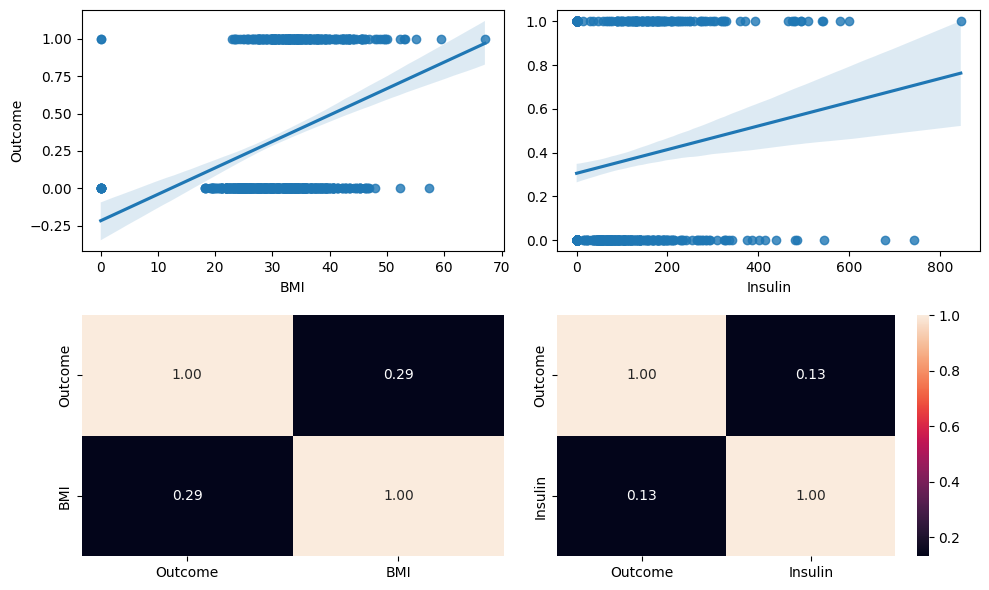

In [9]:
fig, axis = plt.subplots(2, 2, figsize = (10, 6))

# Crear un diagrama de dispersión múltiple
sns.regplot(ax = axis[0, 0], data = df, x = "BMI", y = "Outcome")
sns.heatmap(df[["Outcome", "BMI"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)

sns.regplot(ax = axis[0, 1], data = df, x = "Insulin", y = "Outcome").set(ylabel=None)
sns.heatmap(df[["Outcome", "Insulin"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1])

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

Conclusiones:
Se visualiza que existe una correlación muy debil entre valor insulina y el diagnóstico de diabetes del paciente. 
Se visualiza que hay una relación baja entre el índice de masa corporal y el diagnostico de diabetes del paciente.


bmi-insulin

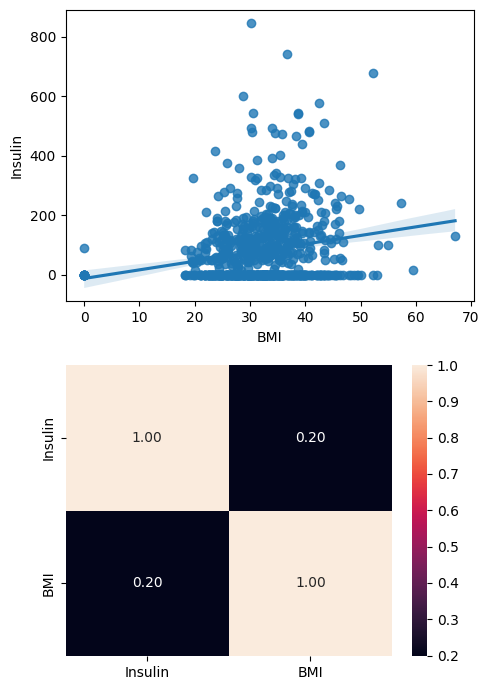

In [10]:
fig, axis = plt.subplots(2, 1, figsize = (5, 7))

# Crear un diagrama de dispersión múltiple
sns.regplot(ax = axis[0], data = df, x = "BMI", y = "Insulin")
sns.heatmap(df[["Insulin", "BMI"]].corr(), annot = True, fmt = ".2f", ax = axis[1])

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

Se visuaiza que no existe una relación muy fuerte entre ambas variables, el índice de masa coporabl no impacta en el valor de insulina del paciente.

6. Análisis categórico-categórico

Para este ejercicio, solo se tiene una variable categórica binaria, por lo que este apartado se va a saltar, ya que no aplica.

ANNÁLISIS DE CORRELACIONES

En este apartado toca revisar las correlacciones de las variables categóricas-categóricas, para esto se realiza primero una factorización y así poder hacer el mapa de calor.
Como se mencionó antes, este ejercicio solo tiene una variable categórico, nos saltaremos este apartado.
Acontinuación, haremos el análisis numérico categórico.

#### 5.2. Análisis numérico-categórico (completo)

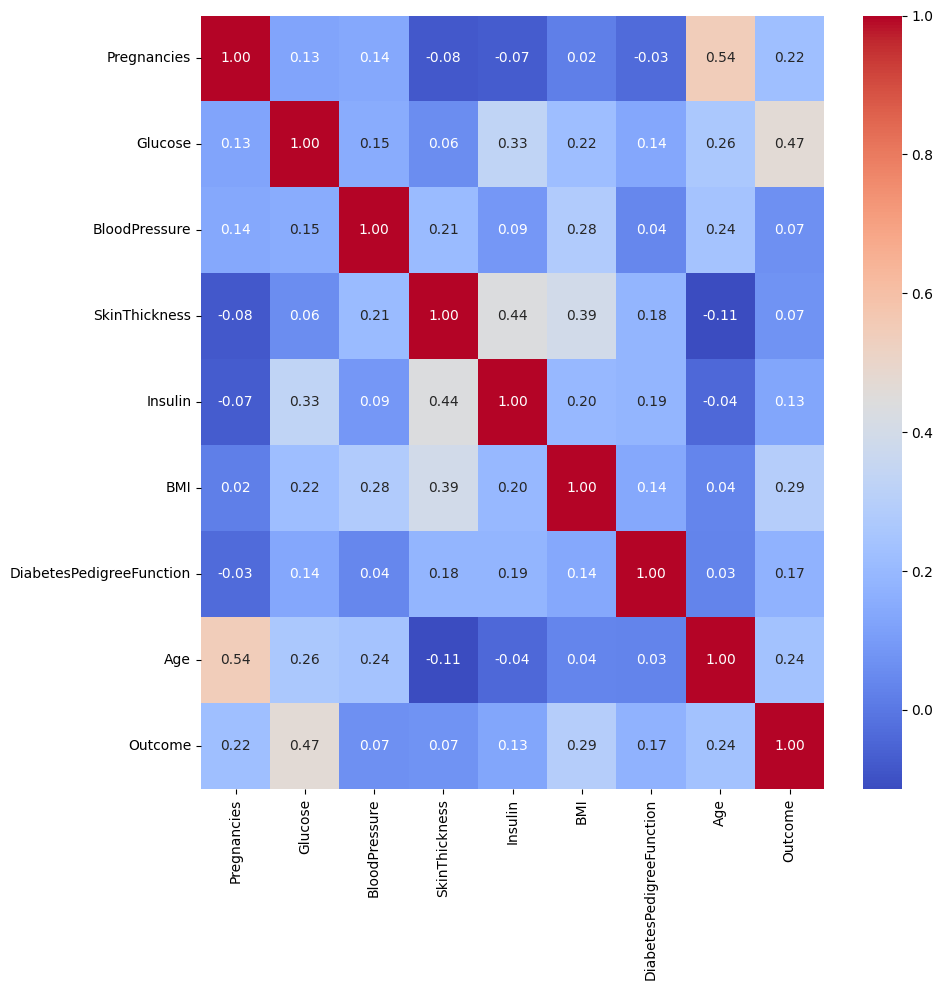

In [11]:
fig, axis = plt.subplots(figsize = (10, 10))

sns.heatmap(df[[
        "Pregnancies",
        "Glucose",
        "BloodPressure",
        "SkinThickness",
        "Insulin",
        "BMI",
        "DiabetesPedigreeFunction",
        "Age",
        "Outcome"]].corr(),annot = True,fmt = ".2f",cmap = "coolwarm")
plt.tight_layout()

plt.show()

Conclusiones:
Existe una correlación moderada entre age y pregnaancies (0.54). Esto puede indicar que paciente de más edad tienden a tener embarazos.

Existe una correlación positiva etre glucose y oucome (0.47). Esto puede decir que mientras se tengan niveles de glucosa altos hay mayor probabilidad de que el paciente tenga diabetes.
Si bien no es una correlación fuerte, pero si se considerada moderada. por lo que a continuación se realizará el gráfico de dispersión para revisar al relación.

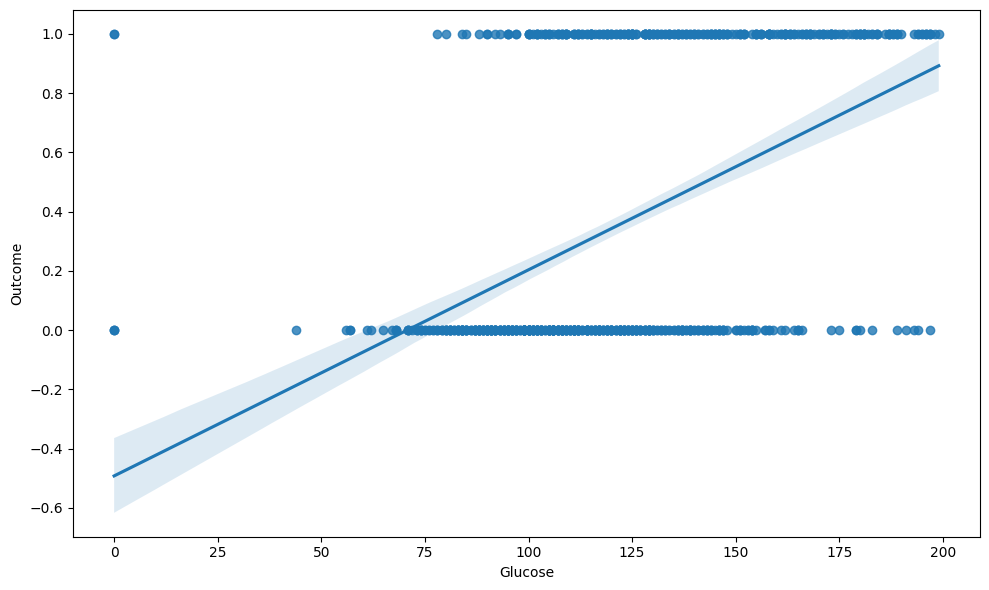

In [12]:
fig, axis = plt.subplots(figsize = (10, 6), ncols = 1)

sns.regplot( data = df, x = "Glucose", y = "Outcome")


plt.tight_layout()

plt.show()

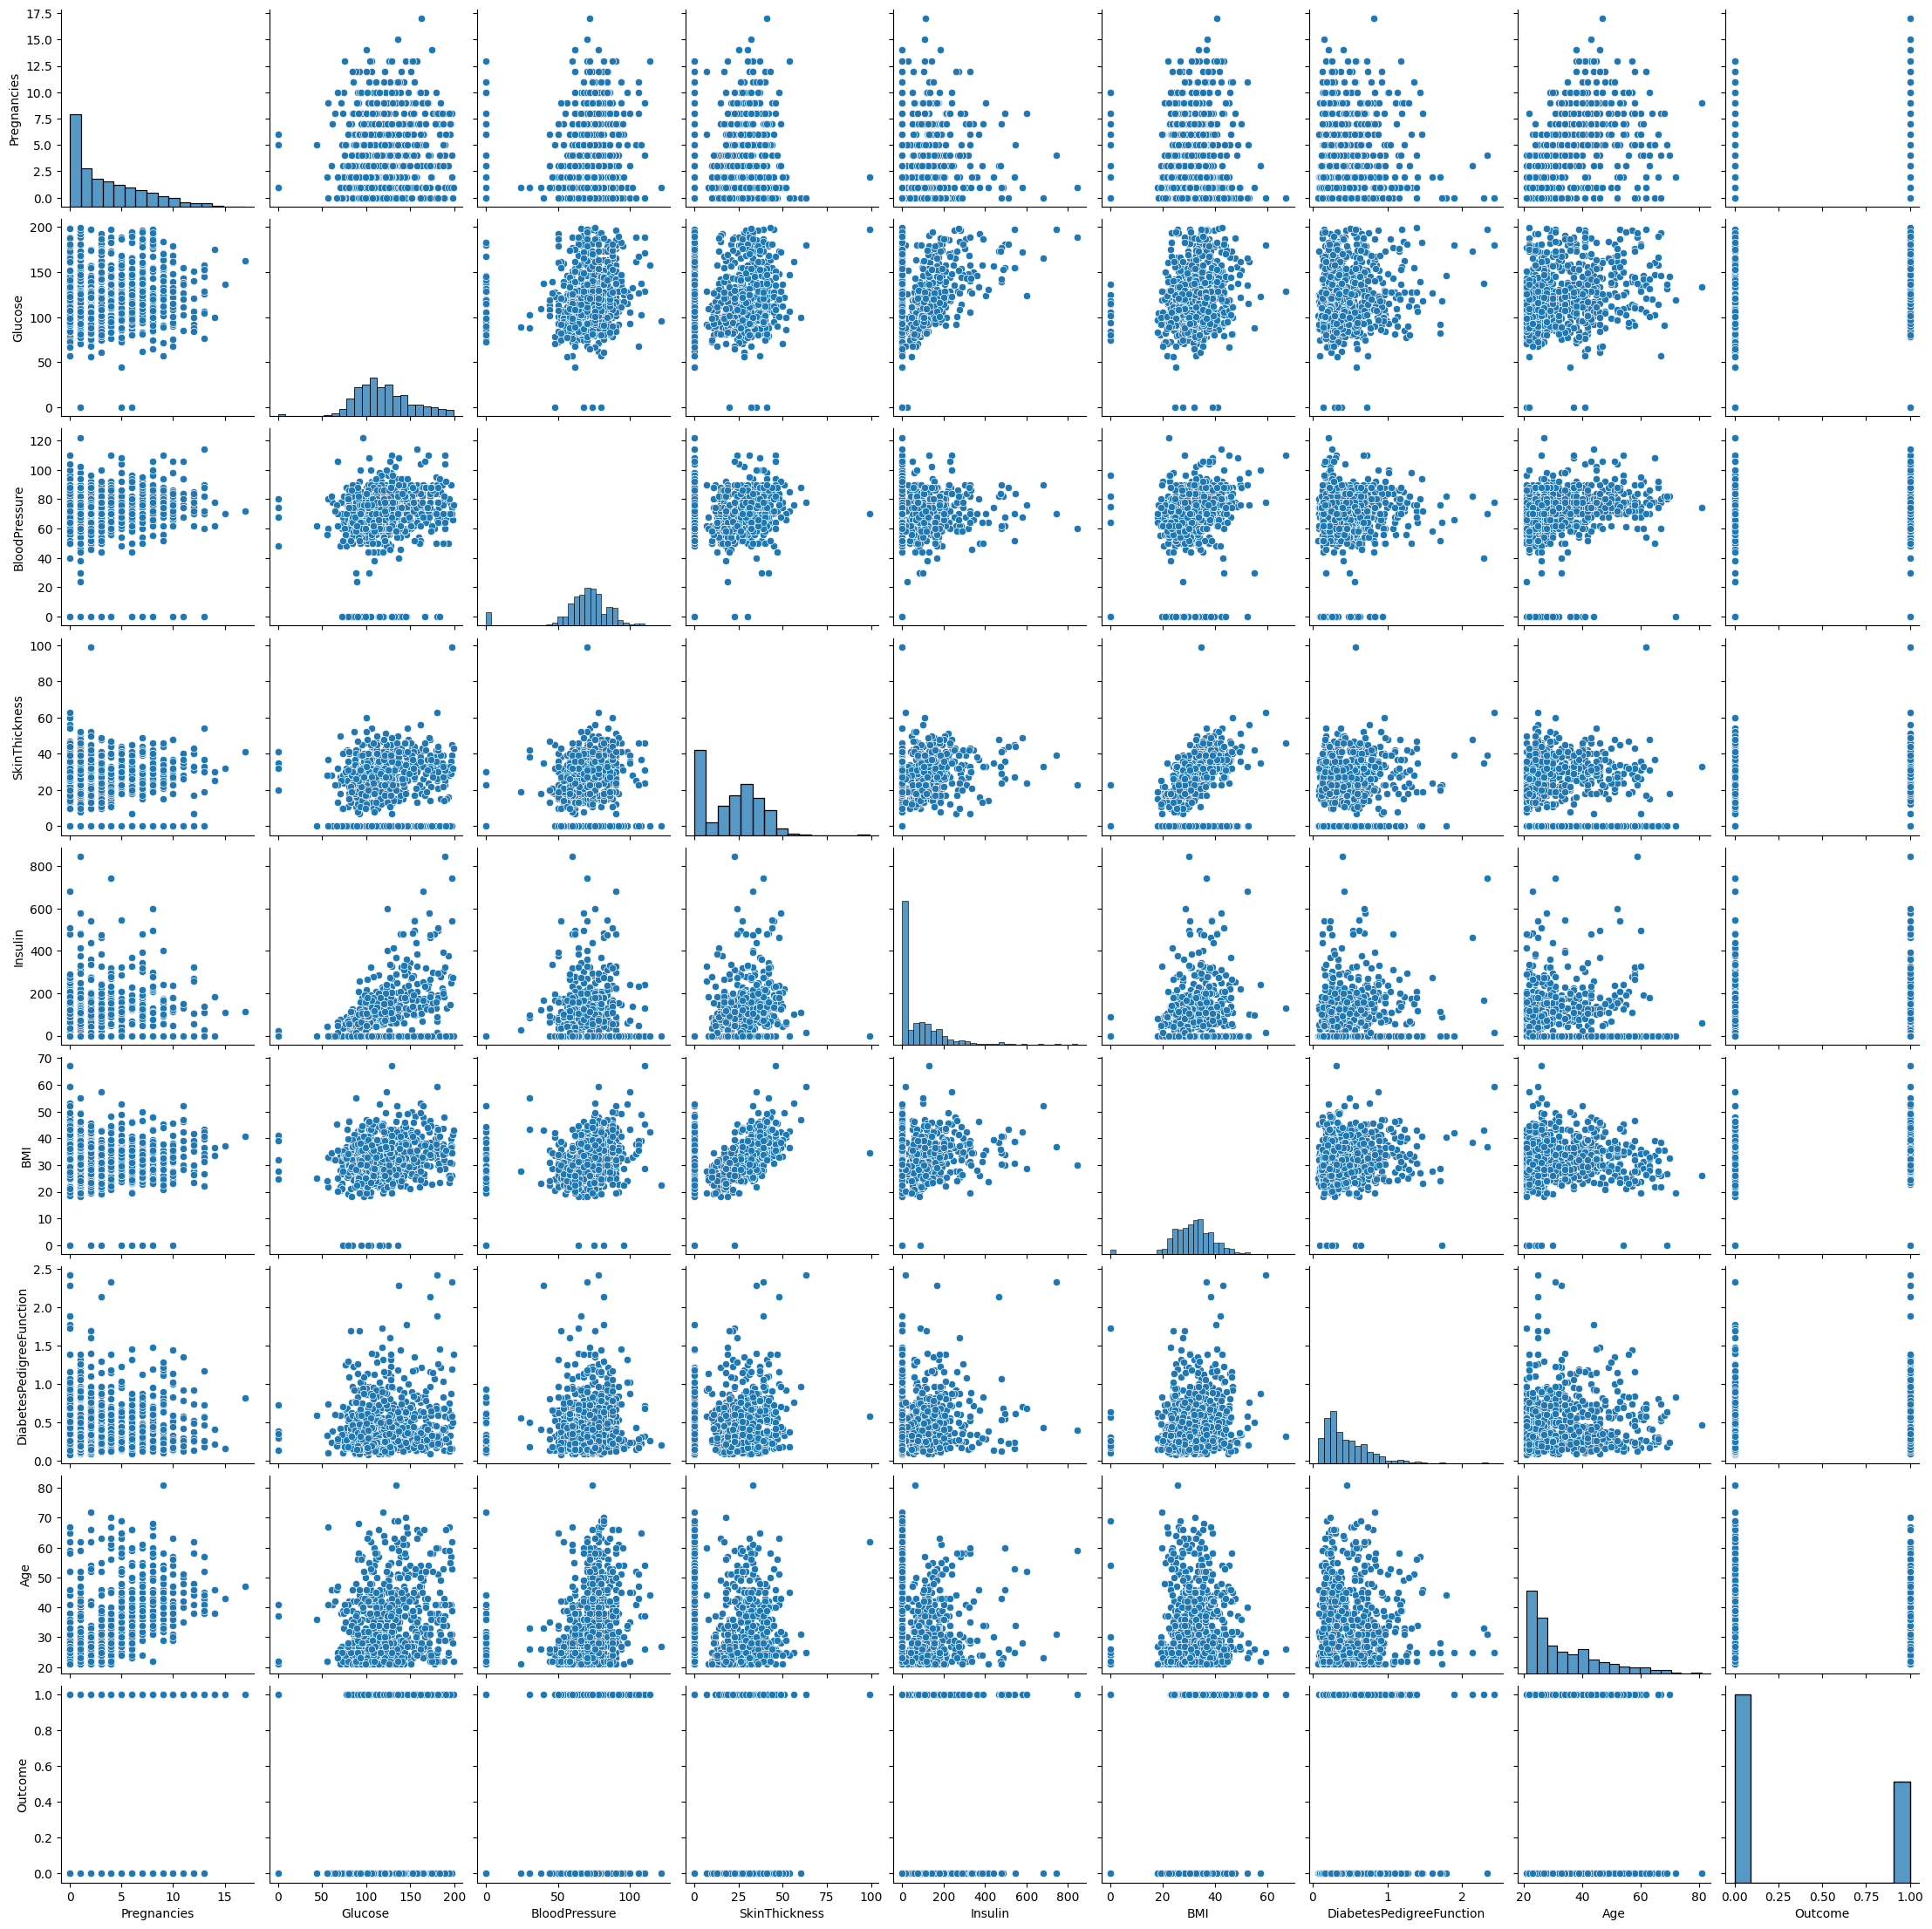

In [13]:
sns.pairplot(data = df)

EDA-PARTE2

1. Valores atípicos

In [14]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


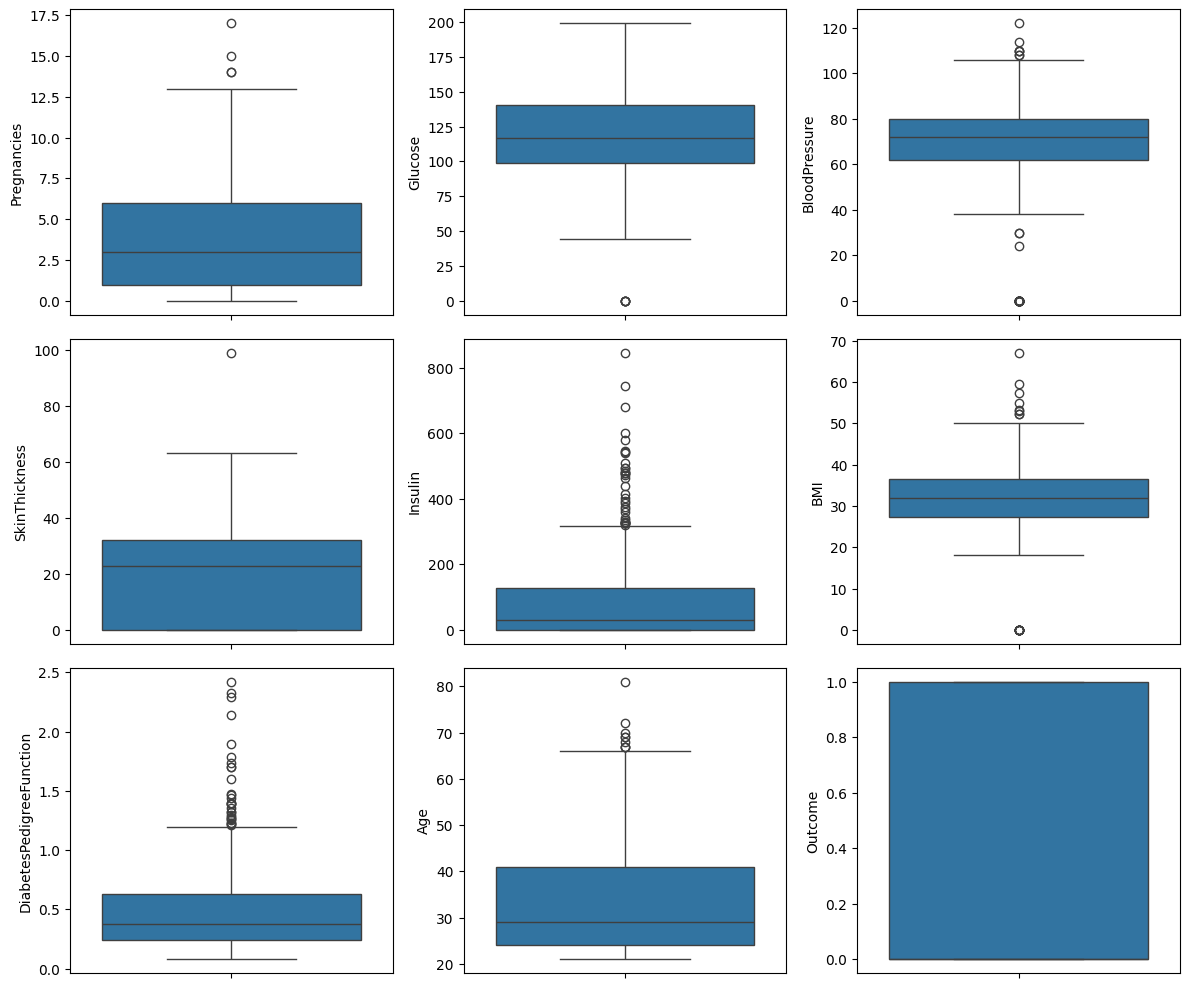

In [15]:

fig, axis = plt.subplots(3, 3, figsize=(12, 10))

sns.boxplot(ax=axis[0, 0], data=df, y="Pregnancies")
sns.boxplot(ax=axis[0, 1], data=df, y="Glucose")
sns.boxplot(ax=axis[0, 2], data=df, y="BloodPressure")

sns.boxplot(ax=axis[1, 0], data=df, y="SkinThickness")
sns.boxplot(ax=axis[1, 1], data=df, y="Insulin")
sns.boxplot(ax=axis[1, 2], data=df, y="BMI")

sns.boxplot(ax=axis[2, 0], data=df, y="DiabetesPedigreeFunction")
sns.boxplot(ax=axis[2, 1], data=df, y="Age")
sns.boxplot(ax=axis[2, 2], data=df, y="Outcome")

plt.tight_layout()

plt.show()

Conclusiones:
Según los valores estádisticos y los boxplot. Se cosnidea relevantee, revisar los valores atípicos de llas variables insulin y  diabetesPedigree

Atípicos- insulin

In [16]:
# Calcular el primer cuartil (Q1) y el tercer cuartil (Q3)
Q1 = df['Insulin'].quantile(0.25)
Q3 = df['Insulin'].quantile(0.75)
IQR = Q3 - Q1

# Definir los límites inferior y superior
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print(f"Los límites superior e inferior para la búsqueda de outliers son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(IQR, 2)}")

Los límites superior e inferior para la búsqueda de outliers son 318.12 y -190.88, con un rango intercuartílico de 127.25


Aquí se tiene que los niveles de insulina mayor a 348.12se consideran outliers. por lo que se revisará los registros que ocupan estos atípicos.

In [17]:
insulin_alto= df[df["Insulin"] >= 318.12]

insulin_alto.head()
insulin_alto.shape


(34, 9)

In [18]:
insulin_alto.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
8,2,197,70,45,543,30.5,0.158,53,1
13,1,189,60,23,846,30.1,0.398,59,1
54,7,150,66,42,342,34.7,0.718,42,0
111,8,155,62,26,495,34.0,0.543,46,1
139,5,105,72,29,325,36.9,0.159,28,0


Los clasificados outliers en insulin ocupan 34 registros, lo que es 4% del dataset, de estas fiilas se revisará que valores outcome tiene.

In [19]:
insulin_alto.Outcome.value_counts()

Outcome
1    19
0    15
Name: count, dtype: int64

Conclusión final:
Se considera mantener los atípicos de insulina, si bien los outliers ocupan un 4% del dataset. Dentro de esos outliers, los valores de outcome so muy euqilibrados, por lo cual se considera no eliminar.


atípicos- DiabetesPedigreeFunction

In [20]:
# Calcular el primer cuartil (Q1) y el tercer cuartil (Q3)
Q1_ = df['DiabetesPedigreeFunction'].quantile(0.25)
Q3_ = df['DiabetesPedigreeFunction'].quantile(0.75)
IQR_ = Q3_ - Q1_

# Definir los límites inferior y superior
lower_limit_ = Q1_ - 1.5 * IQR_
upper_limit_ = Q3_ + 1.5 * IQR_

print(f"Los límites superior e inferior para la búsqueda de outliers son {round(upper_limit_, 2)} y {round(lower_limit_, 2)}, con un rango intercuartílico de {round(IQR_, 2)}")

Los límites superior e inferior para la búsqueda de outliers son 1.2 y -0.33, con un rango intercuartílico de 0.38


Aquí se tiene que los valores de diabetepedigree mayor a 1.2 se consideran outliers. por lo que se revisará los registros que ocupan estos atípicos.

In [21]:
diabetes_alto= df[df["DiabetesPedigreeFunction"] >= 1.2]

diabetes_alto.shape



(29, 9)

In [22]:
diabetes_alto.Outcome.value_counts()

Outcome
1    17
0    12
Name: count, dtype: int64

si  bien, los outliers de pedigree resultan ser 3.8% del dataset, este campo tambiñén tiene valores de outcome equilibrados, por lo que se decide no eliminar outliers. Similar al análisis de insulin.

2. Valores faltantes

In [23]:
df.isnull().sum().sort_values(ascending=False)

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

No se encontraron nvalores nulos en el dataset.

3. Ingeniería de atributos

3.1. Clasificación de BMI

Se plantea clasificar los valores bmi según la clasificación de la oms.

El criterio sería el siguiente:

bajo_peso: BMI menor a 18.5

normal: BMI entre 18.5 y 24.9

sobrepeso: BMI entre 25.0 y 29.9

obesidad_grado1: BMI entre 30.0 y 34.9

obesidad_grado2: BMI entre 35.0 y 39.9

obesidad_grado3: BMI de 40.0 o más

In [24]:
def clasificar_bmi(bmi):
    if bmi < 18.5:
        return "bajo_peso"
    elif bmi < 25:
        return "normal"
    elif bmi < 30:
        return "sobrepeso"
    elif bmi < 35:
        return "obesidad_grado1"
    elif bmi < 40:
        return "obesidad_grado2"
    else:
        return "obesidad_grado3"

df['BMI_categoria'] = df['BMI'].apply(clasificar_bmi)


print(df['BMI_categoria'].value_counts())

BMI_categoria
obesidad_grado1    224
sobrepeso          179
obesidad_grado2    150
normal             102
obesidad_grado3     98
bajo_peso           15
Name: count, dtype: int64


3.2. Clasificación en pregnancies

Se añadi una clasificación por pregnancies,, si es 0 es que el paciente no tiene pregnancies, lo que eqeuivale 0, y si tuvo embarazos, equivale a 1. 

Así se traduce a clasificar los pacientes por dos grupos n(si tuvo emabrazos, no tuvo embarazos)

In [25]:
df["tiene_pregnancies"] = df["Pregnancies"].apply(lambda x: 0 if x == 0 else 1)

#0: no tiene embarazos
#1: si tuvo embarazos

In [26]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_categoria,tiene_pregnancies
0,6,148,72,35,0,33.6,0.627,50,1,obesidad_grado1,1
1,1,85,66,29,0,26.6,0.351,31,0,sobrepeso,1
2,8,183,64,0,0,23.3,0.672,32,1,normal,1
3,1,89,66,23,94,28.1,0.167,21,0,sobrepeso,1
4,0,137,40,35,168,43.1,2.288,33,1,obesidad_grado3,0


4. train/test split

Dividir el dataset en train y test

80% → entrenamiento

20% → prueba

In [27]:
X=df.drop("Outcome",axis=1)   #variable predictora
y=df["Outcome"]               #variable objetivo


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,BMI_categoria,tiene_pregnancies
60,2,84,0,0,0,0.0,0.304,21,bajo_peso,1
618,9,112,82,24,0,28.2,1.282,50,sobrepeso,1
346,1,139,46,19,83,28.7,0.654,22,sobrepeso,1
294,0,161,50,0,0,21.9,0.254,65,normal,0
231,6,134,80,37,370,46.2,0.238,46,obesidad_grado3,1


In [28]:
X_train.shape, X_test.shape

((614, 10), (154, 10))

5. Escalado

Se realiza el escalado de variables numéricas mediante `StandardScaler`, con el fin de normalizar los datos y llevarlos a una escala comparable.

In [29]:
# Variables numéricas, SOLO SE CONSIDERAN LAS VARIABLES NUMÉRICAS CONTINUAS, 
# LAS NUEVAS CATGEGORIAS DE INGENIERA DE ATRIUTOS IRAN EN ENCODING
num_variables = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

In [30]:
# instancio el escalador
scaler = StandardScaler()

# entreno el escalador con los datos de entrenamiento
scaler.fit(X_train[num_variables])

# aplico el escalador en amhos
X_train_num_scal = scaler.transform(X_train[num_variables])
X_train_num_scal = pd.DataFrame(X_train_num_scal, index = X_train.index, columns = num_variables)

X_test_num_scal = scaler.transform(X_test[num_variables])
X_test_num_scal = pd.DataFrame(X_test_num_scal, index = X_test.index, columns = num_variables)

X_train_num_scal.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
60,-0.526397,-1.151398,-3.752683,-1.322774,-0.701206,-4.135256,-0.490735,-1.035940
618,1.588046,-0.276643,0.680345,0.233505,-0.701206,-0.489169,2.415030,1.487101
346,-0.828460,0.566871,-1.265862,-0.090720,0.013448,-0.424522,0.549161,-0.948939
294,-1.130523,1.254179,-1.049617,-1.322774,-0.701206,-1.303720,-0.639291,2.792122
231,0.681856,0.410665,0.572222,1.076490,2.484601,1.838121,-0.686829,1.139095


In [31]:
# instancio el escalador
scaler = MinMaxScaler()

# entreno el escalador con los datos de entrenamiento

scaler.fit(X_train[num_variables])

# aplico el escalador en amhos
X_train_num_mm = scaler.transform(X_train[num_variables])
X_train_num_mm = pd.DataFrame(X_train_num_mm, index = X_train.index, columns = num_variables)

X_test_num_mm = scaler.transform(X_test[num_variables])
X_test_num_mm = pd.DataFrame(X_test_num_mm, index = X_test.index, columns = num_variables)

X_train_num_mm.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
60,0.117647,0.422111,0.000000,0.000000,0.000000,0.000000,0.096499,0.000000
618,0.529412,0.562814,0.672131,0.380952,0.000000,0.420268,0.514091,0.483333
346,0.058824,0.698492,0.377049,0.301587,0.098109,0.427720,0.245944,0.016667
294,0.000000,0.809045,0.409836,0.000000,0.000000,0.326379,0.075149,0.733333
231,0.352941,0.673367,0.655738,0.587302,0.437352,0.688525,0.068318,0.416667


5. encoding

Las variables categóricas, que contienen valores discretos y no numéricos, deben transformarse en una forma que los algoritmos de ML puedan entender.

Existen varias técnicas de codificación, cada una con sus ventajas y desventajas, dependiendo del tipo de datos y del modelo utilizado.

In [32]:
cat_variables = ["BMI_categoria"]

Se utuilizará la técnica one-hot encoding porquelas vairbales no tienen orden natural.

In [33]:
# instancio el encoder
onehot_encoder = OneHotEncoder(sparse_output=False)

# entreno el encoder con los datos de entrenamiento
onehot_encoder.fit(X_train[cat_variables])

# aplico el encoder en amhos
X_train_cat_ohe = onehot_encoder.transform(X_train[cat_variables])
X_train_cat_ohe = pd.DataFrame(X_train_cat_ohe, index = X_train.index, columns=onehot_encoder.get_feature_names_out(cat_variables))

X_test_cat_ohe = onehot_encoder.transform(X_test[cat_variables])
X_test_cat_ohe = pd.DataFrame(X_test_cat_ohe, index = X_test.index, columns=onehot_encoder.get_feature_names_out(cat_variables))

X_train_cat_ohe.head()

,BMI_categoria_bajo_peso,BMI_categoria_normal,BMI_categoria_obesidad_grado1,BMI_categoria_obesidad_grado2,BMI_categoria_obesidad_grado3,BMI_categoria_sobrepeso
60,1.0,0.0,0.0,0.0,0.0,0.0
618,0.0,0.0,0.0,0.0,0.0,1.0
346,0.0,0.0,0.0,0.0,0.0,1.0
294,0.0,1.0,0.0,0.0,0.0,0.0
231,0.0,0.0,0.0,0.0,1.0,0.0


EDA-PARTE 3

1. Selección de características

En esta parte se usa estadístico de prueba para seleccionar las variables importantes


unificar dataset preprocesado

In [34]:
# unificamos el dataset preprocesado hasta el momento
X_train_final = pd.concat([X_train_num_scal, X_train_cat_ohe], axis=1)
X_test_final = pd.concat([X_test_num_scal, X_test_cat_ohe], axis=1)

X_train_final.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,BMI_categoria_bajo_peso,BMI_categoria_normal,BMI_categoria_obesidad_grado1,BMI_categoria_obesidad_grado2,BMI_categoria_obesidad_grado3,BMI_categoria_sobrepeso
60,-0.526397,-1.151398,-3.752683,-1.322774,-0.701206,-4.135256,-0.490735,-1.035940,1.0,0.0,0.0,0.0,0.0,0.0
618,1.588046,-0.276643,0.680345,0.233505,-0.701206,-0.489169,2.415030,1.487101,0.0,0.0,0.0,0.0,0.0,1.0
346,-0.828460,0.566871,-1.265862,-0.090720,0.013448,-0.424522,0.549161,-0.948939,0.0,0.0,0.0,0.0,0.0,1.0
294,-1.130523,1.254179,-1.049617,-1.322774,-0.701206,-1.303720,-0.639291,2.792122,0.0,1.0,0.0,0.0,0.0,0.0
231,0.681856,0.410665,0.572222,1.076490,2.484601,1.838121,-0.686829,1.139095,0.0,0.0,0.0,0.0,1.0,0.0


In [35]:
X_train_final.info()

<class 'pandas.DataFrame'>
Index: 614 entries, 60 to 102
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Pregnancies                    614 non-null    float64
 1   Glucose                        614 non-null    float64
 2   BloodPressure                  614 non-null    float64
 3   SkinThickness                  614 non-null    float64
 4   Insulin                        614 non-null    float64
 5   BMI                            614 non-null    float64
 6   DiabetesPedigreeFunction       614 non-null    float64
 7   Age                            614 non-null    float64
 8   BMI_categoria_bajo_peso        614 non-null    float64
 9   BMI_categoria_normal           614 non-null    float64
 10  BMI_categoria_obesidad_grado1  614 non-null    float64
 11  BMI_categoria_obesidad_grado2  614 non-null    float64
 12  BMI_categoria_obesidad_grado3  614 non-null    float64
 13  BMI_c

Se aplicó SelectKBest con el estadístico f_classif para seleccionar las variables más relevantes.

In [36]:
# Con un valor de k = 8 deci
selection_model = SelectKBest(score_func = f_classif, k = 8)

# entreno la seleecion
selection_model.fit(X_train_final, y_train)

ix = selection_model.get_support()
X_train_sel = pd.DataFrame(selection_model.transform(X_train_final), columns = X_train_final.columns.values[ix])
X_test_sel = pd.DataFrame(selection_model.transform(X_test_final), columns = X_test_final.columns.values[ix])

X_train_sel.head()

,Pregnancies,Glucose,BMI,DiabetesPedigreeFunction,Age,BMI_categoria_normal,BMI_categoria_obesidad_grado3,BMI_categoria_sobrepeso
0,-0.526397,-1.151398,-4.135256,-0.490735,-1.035940,0.0,0.0,0.0
1,1.588046,-0.276643,-0.489169,2.415030,1.487101,0.0,0.0,1.0
2,-0.828460,0.566871,-0.424522,0.549161,-0.948939,0.0,0.0,1.0
3,-1.130523,1.254179,-1.303720,-0.639291,2.792122,1.0,0.0,0.0
4,0.681856,0.410665,1.838121,-0.686829,1.139095,0.0,1.0,0.0


In [37]:
# Obtener las características seleccionadas
selected_features = X_train_final.columns[selection_model.get_support()]

selected_features

Index(['Pregnancies', 'Glucose', 'BMI', 'DiabetesPedigreeFunction', 'Age',
       'BMI_categoria_normal', 'BMI_categoria_obesidad_grado3',
       'BMI_categoria_sobrepeso'],
      dtype='str')

In [38]:
X_train_sel["Outcome"] = y_train.values
X_test_sel["Outcome"] = y_test.values

X_train_sel.to_csv("../data/processed/clean_train.csv", index=False)
X_test_sel.to_csv("../data/processed/clean_test.csv", index=False)

MODELADO

In [39]:
#traer la data preprocesada
train_data=pd.read_csv("../data/processed/clean_train.csv")
test_data = pd.read_csv("../data/processed/clean_test.csv")

train_data.head()

,Pregnancies,Glucose,BMI,DiabetesPedigreeFunction,Age,BMI_categoria_normal,BMI_categoria_obesidad_grado3,BMI_categoria_sobrepeso,Outcome
0,-0.526397,-1.151398,-4.135256,-0.490735,-1.035940,0.0,0.0,0.0,0
1,1.588046,-0.276643,-0.489169,2.415030,1.487101,0.0,0.0,1.0,1
2,-0.828460,0.566871,-0.424522,0.549161,-0.948939,0.0,0.0,1.0,0
3,-1.130523,1.254179,-1.303720,-0.639291,2.792122,1.0,0.0,0.0,0
4,0.681856,0.410665,1.838121,-0.686829,1.139095,0.0,1.0,0.0,1


Train se usa para entrenar el modelo, mimentras que test se usa para evaluar para medir su grado de efectividad.

separar X, y

In [40]:
# Separar X e y
X_train = train_data.drop(["Outcome"], axis = 1)
y_train = train_data["Outcome"]

X_test = test_data.drop(["Outcome"], axis = 1)
y_test = test_data["Outcome"]

A continuación de utilizará los árboles de clasificación. porque la variable objetivo es binaria.

In [41]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report
from pickle import dump


model = DecisionTreeClassifier(random_state = 42)

# entrenamiento
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

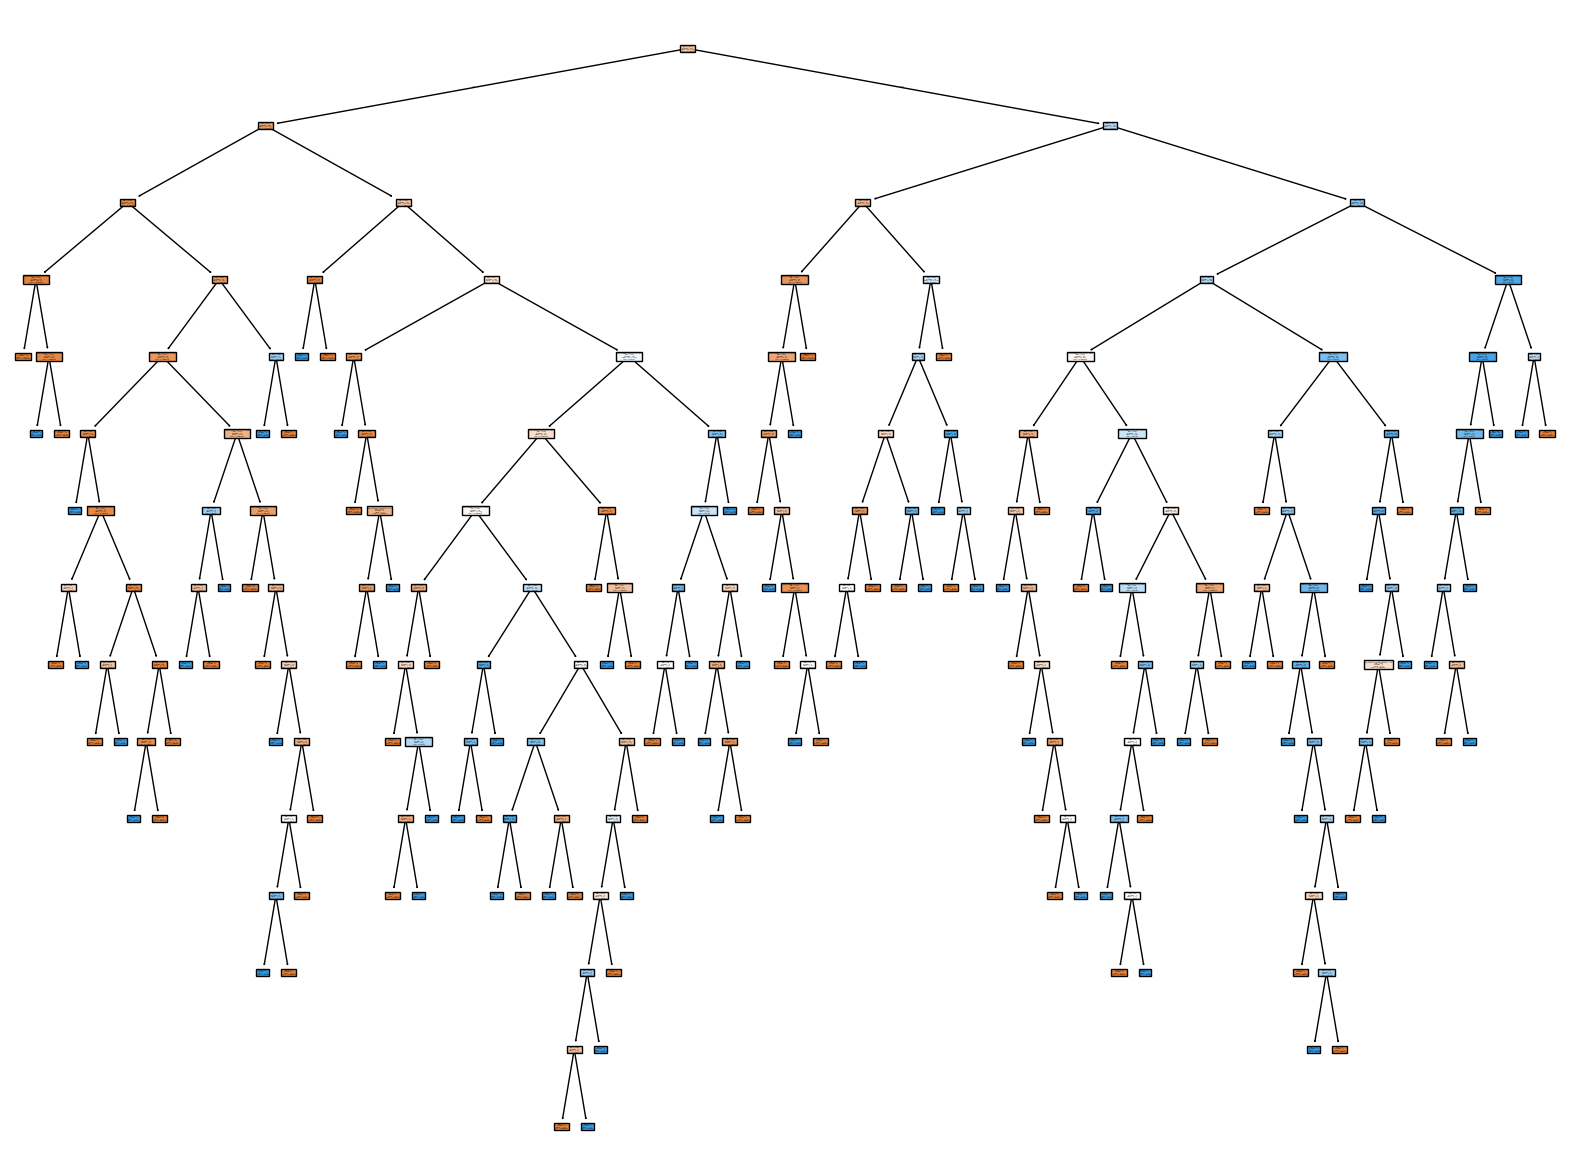

In [42]:
fig = plt.figure(figsize=(20,15))

tree.plot_tree(model, feature_names = list(X_train.columns), class_names = ["No diabetes", "Diabetes"], filled = True)

plt.show()

In [43]:
# predicción
y_pred_test = model.predict(X_test)
y_pred_test

array([0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0])

In [44]:
y_pred_train = model.predict(X_train)
y_pred_train

array([0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0,

In [45]:
# metricas
accuracy_test = accuracy_score(y_test, y_pred_test)
accuracy_train = accuracy_score(y_train, y_pred_train)

f1_score_test = f1_score(y_test, y_pred_test, average='micro')
f1_score_train = f1_score(y_train, y_pred_train, average='micro')

precision_test = precision_score(y_test, y_pred_test, average='micro')
precision_train = precision_score(y_train, y_pred_train, average='micro')

recall_test = recall_score(y_test, y_pred_test, average='micro')
recall_train = recall_score(y_train, y_pred_train, average='micro')

print("Accuracy Test: ", accuracy_test)
print("F1 score Test: ", f1_score_test)
print("Precision Test: ", precision_test)
print("Recall Test: ", recall_test)

print("Accuracy Train: ", accuracy_train)
print("F1 score Train: ", f1_score_train)
print("Precision Train: ", precision_train)
print("Recall Train: ", recall_train)

Accuracy Test:  0.7272727272727273
F1 score Test:  0.7272727272727273
Precision Test:  0.7272727272727273
Recall Test:  0.7272727272727273
Accuracy Train:  1.0
F1 score Train:  1.0
Precision Train:  1.0
Recall Train:  1.0


In [46]:
print(classification_report(
    y_test,
    y_pred_test,
    target_names=["Negativa (0)", "Positiva (1)"],
    digits=3,
    zero_division=0
))

              precision    recall  f1-score   support

Negativa (0)      0.820     0.737     0.777        99
Positiva (1)      0.600     0.709     0.650        55

    accuracy                          0.727       154
   macro avg      0.710     0.723     0.713       154
weighted avg      0.742     0.727     0.731       154



Guardado de modelo

In [47]:
dump(model, open("decision_tree_classifier_default_42.sav", "wb"))

Conclusiones:

Utilizando el árbol de decisión de tipo clasificaciónn se visualiza que se tiene un accuracy de 0.72, por loq ue se considera que el modelo es aceptable. Se ve que la capacidad de predecir bienn los verdaderos positivos es de 0.7 en recall. Esto significa que de cada 10 pacientes que si tuvieron diabetes, el modelo acierta en identificar 7 de estos.

Optimizar modelo

In [48]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn


In [49]:
# Definimos los parámetros que queremos ajustar a mano
hyperparams = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Inicializamos la cuadrícula
grid = GridSearchCV(model, hyperparams, scoring = "accuracy", cv = 5)
grid

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold a

In [50]:
grid.fit(X_train, y_train)

print(f"Mejores hiperparámetros: {grid.best_params_}")

Mejores hiperparámetros: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [51]:
model_grid = DecisionTreeClassifier(
    criterion = "entropy",
    max_depth = 5,
    min_samples_split = 2,
    min_samples_leaf = 1,
    random_state = 42
)

# Entrenamiento del modelo
model_grid.fit(X_train, y_train)
# Predicción
y_pred = model_grid.predict(X_test)
# Métrica accuracy
grid_accuracy = accuracy_score(y_test, y_pred)

grid_accuracy

0.7922077922077922

Conclusión:
Se aplicó la técnica de optimización gridsearch y finalmente se obtuvo un valor accuracy mayor al inicial, este es 0.79. Por lo que se considera que el modelo si mejoró.

Los  hiperparmetros encontrados fueron:
criterion = "entropy"
max_depth = 5
min_samples_split = 2
min_samples_leaf = 1


sin embargo, existe  aún un margen de mejroa para el modelo.
